#1. Import Libraries



In [3]:

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Word Cloud
from wordcloud import WordCloud

# Save Model
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


#2. Download NLTK Resources

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK resources downloaded successfully!


#3. Load Dataset

In [8]:
fake_df = pd.read_csv("Fake.csv.zip")
true_df = pd.read_csv("True.csv.zip")

print("Datasets loaded successfully!")

Datasets loaded successfully!


# 4.Display Dataset

In [9]:
print("Fake News Dataset")
display(fake_df.head())

print("\nReal News Dataset")
display(true_df.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



Real News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


#5. Dataset Information

In [10]:
print("Fake Dataset Information")
fake_df.info()

print("\n")

print("Real Dataset Information")
true_df.info()

Fake Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


Real Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


#6. Missing Values

In [11]:
print("Missing Values in Fake Dataset")
print(fake_df.isnull().sum())

print("\n")

print("Missing Values in Real Dataset")
print(true_df.isnull().sum())

Missing Values in Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64


Missing Values in Real Dataset
title      0
text       0
subject    0
date       0
dtype: int64


#7. Dataset Shape

In [12]:
print("Fake Dataset Shape :", fake_df.shape)
print("Real Dataset Shape :", true_df.shape)

Fake Dataset Shape : (23481, 4)
Real Dataset Shape : (21417, 4)


#8. Add Labels

In [13]:
# Fake = 0
fake_df["label"] = 0

# Real = 1
true_df["label"] = 1

print("Labels added successfully!")

display(fake_df.head())
display(true_df.head())

Labels added successfully!


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


#9. Merge Dataset

In [14]:
news_df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print("Combined Dataset Shape :", news_df.shape)

display(news_df.head())

Combined Dataset Shape : (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


#10. Shuffle Dataset

In [15]:
news_df = news_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Dataset shuffled successfully!")

display(news_df.head())

Dataset shuffled successfully!


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


#11. Distribution Plot

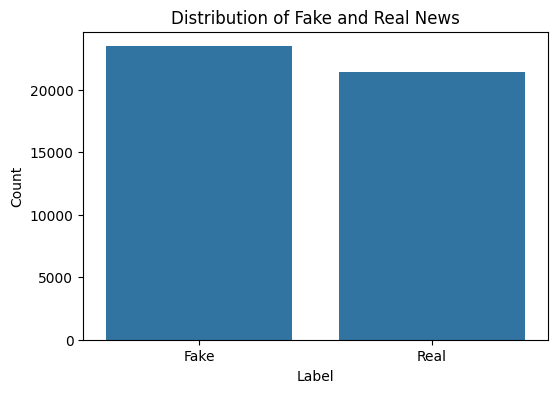

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=news_df
)

plt.title("Distribution of Fake and Real News")

plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(
    [0,1],
    ["Fake","Real"]
)

plt.show()

#12. Text Cleaning

In [17]:
lemmatizer = WordNetLemmatizer()

stop_words = set(
    stopwords.words("english")
)

In [18]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [19]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+','',text)

    text = re.sub(r'<.*?>','',text)

    text = re.sub(r'[^\w\s]','',text)

    text = re.sub(r'\d+','',text)

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("Cleaning function created successfully!")

Cleaning function created successfully!


#13.Apply Cleaning

In [20]:
news_df["clean_text"] = news_df["text"].apply(clean_text)

print("Cleaning completed!")

display(
    news_df[
        ["text","clean_text"]
    ].head()
)

Cleaning completed!


,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire say ben stein reputable profes...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters u president donald trump re...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters u presidential candid...


#14. Features and Target

In [21]:
# Features (Independent Variable)
X = news_df["clean_text"]

# Target (Dependent Variable)
y = news_df["label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (44898,)
Target Shape: (44898,)


#15 TF-IDF Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# Transform text into numerical vectors
X = tfidf.fit_transform(X)

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (44898, 5000)


#16. Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (35918, 5000)
Testing Set Shape: (8980, 5000)


#17. Train Logistic regression





In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [29]:
#Evaluate Logistic Regression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.9869710467706013

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Matrix:

[[4622   74]
 [  43 4241]]


# 18.  Train Multinomial Naive Bayes Model

In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes Model Trained Successfully!")

Naive Bayes Model Trained Successfully!


In [31]:
# Evaluate Multinomial Naive Bayes Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, nb_pred))

Accuracy: 0.9312917594654788

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4696
           1       0.93      0.92      0.93      4284

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980


Confusion Matrix:

[[4408  288]
 [ 329 3955]]


#19. Train Random Forest Model

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [32]:
# Evaluate Random Forest Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9973273942093541

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980


Confusion Matrix:

[[4680   16]
 [   8 4276]]


#20. Train Linear Support Vector Machine (SVM) Model

In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

print("Linear SVM Model Trained Successfully!")

Linear SVM Model Trained Successfully!


In [33]:
# Evaluate Linear Support Vector Machine (SVM) Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.9932071269487751

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Matrix:

[[4661   35]
 [  26 4258]]


#21. Compare Model Performances

In [34]:
import pandas as pd
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Random Forest",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
2,Random Forest,0.997327
3,Linear SVM,0.993207
0,Logistic Regression,0.986971
1,Multinomial Naive Bayes,0.931292


#22. Confusion Matrix Visualization

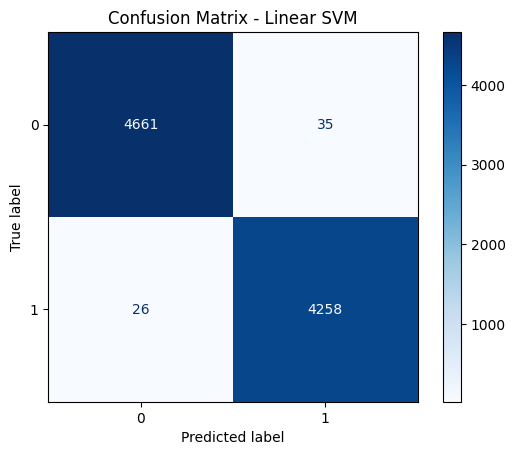

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

#23. Accuracy Comparision Graph

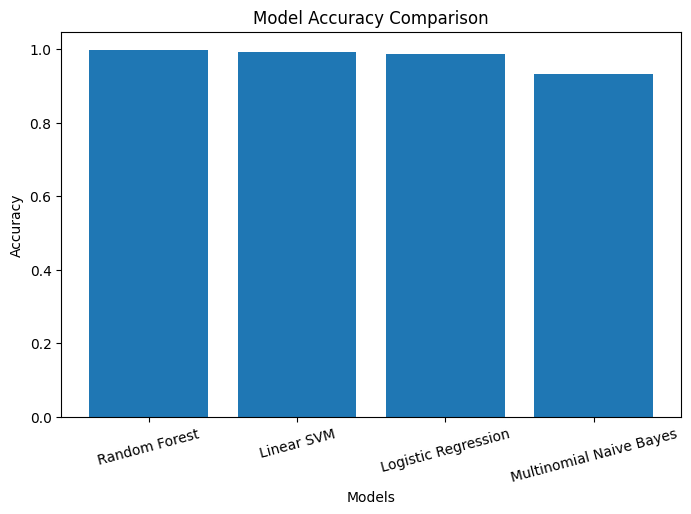

In [36]:
import matplotlib.pyplot as plt

models = comparison["Model"]
accuracy = comparison["Accuracy"]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

#23. Generate Text

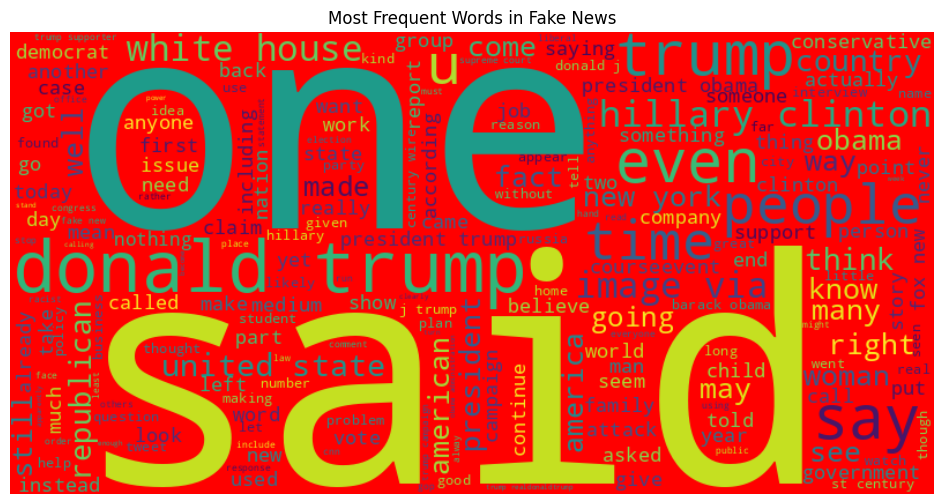

In [41]:
from wordcloud import WordCloud

fake_words = " ".join(news_df[news_df["label"] == 0]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="red"
).generate(fake_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Fake News")
plt.show()

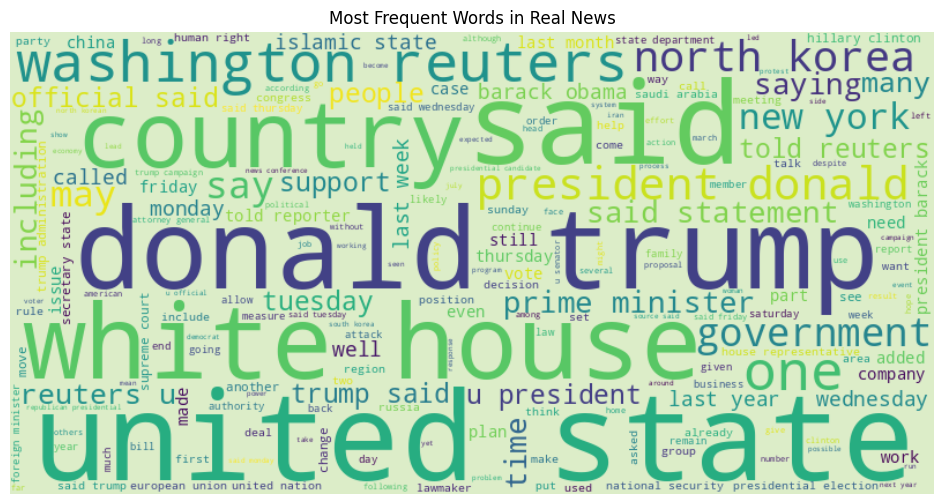

In [43]:
real_words = " ".join(news_df[news_df["label"] == 1]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="#DCEDC8"
).generate(real_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Real News")
plt.show()

#24. Predict Custom News

In [38]:
sample_news = [
    "Scientists discover a new treatment that reduces cancer risk."
]

sample_vector = tfidf.transform(sample_news)

prediction = svm_model.predict(sample_vector)

if prediction[0] == 1:
    print("🟢 Real News")
else:
    print("🔴 Fake News")

🔴 Fake News


#25. Save the Best Model

In [39]:
import joblib

joblib.dump(svm_model, "svm_fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


#